In [1]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [2]:
#load spam data
spam_data=pd.read_csv('spam.csv',encoding="latin-1")

#define tf-idf
tfid=TfidfVectorizer()

In [3]:

y=spam_data["v1"]

#mapping of output to numerical value is done
y=y.map({"ham":0,
        "spam":1})

#convert strings into  numeric
X=tfid.fit_transform(spam_data["v2"])


In [4]:
#split data set into train,val and test data
x_train,x_,y_train,y_=train_test_split(X,y,test_size=0.4,random_state=1234)
x_val,x_test,y_val,y_test=train_test_split(x_,y_,test_size=0.5,random_state=1234)

In [5]:
#list of n_estimator
n_estimator_list=[50,100,200,300,500]


In [6]:
#define list of train and validation accuracy
train_accuracy_list=[]
val_accuracy_list=[]

for n_estimator in n_estimator_list:

    #train XGB model on train data
    model=XGBClassifier(n_estimators=n_estimator,random_state=1234)
    model.fit(x_train,y_train)

    #predict train and validation data
    y_train_cap=model.predict(x_train)
    y_val_cap=model.predict(x_val)

    #find accuracy of train and validation
    train_acc=accuracy_score(y_train,y_train_cap)
    val_acc=accuracy_score(y_val,y_val_cap)

    #add accuracy of train and validation to list
    train_accuracy_list.append(train_acc)
    val_accuracy_list.append(val_acc)

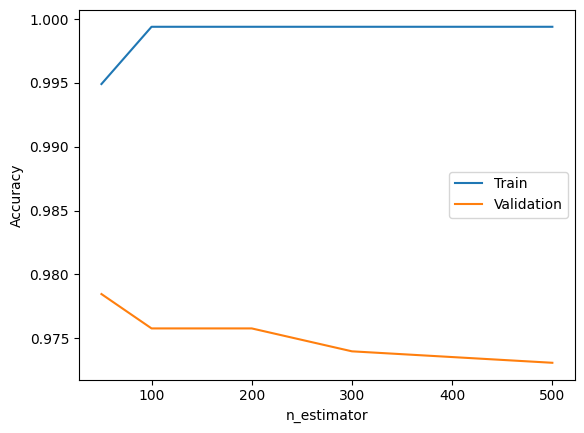

In [7]:
#plot graph
plt.plot(n_estimator_list,train_accuracy_list)
plt.plot(n_estimator_list,val_accuracy_list)
plt.xlabel('n_estimator')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

In [8]:
#find optimal n estimator
index=np.argmax(val_accuracy_list)
n_estimator=n_estimator_list[index]
n_estimator

50

In [9]:
#list of max depth
max_depth_list=[2, 3, 4, 5, 6, 8, 10]


In [10]:
#list of train and accuracy list
train_accuracy_list=[]
val_accuracy_list=[]
for max_depth in max_depth_list:

    #train xgb classifier model
    model=XGBClassifier(n_estimators=n_estimator,max_depth=max_depth,random_state=1234)
    model.fit(x_train,y_train)

    #predict train and test model
    y_train_cap=model.predict(x_train)
    y_val_cap=model.predict(x_val)

    #find accuracy of train and test
    train_acc=accuracy_score(y_train,y_train_cap)
    val_acc=accuracy_score(y_val,y_val_cap)

    #add accuracy to list
    train_accuracy_list.append(train_acc)
    val_accuracy_list.append(val_acc)

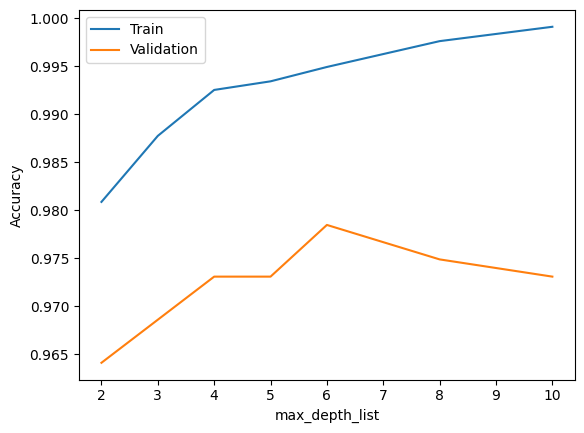

In [11]:
#plot graph
plt.plot(max_depth_list,train_accuracy_list)
plt.plot(max_depth_list,val_accuracy_list)
plt.xlabel('max_depth_list')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

In [12]:
#find optimal depth
index=np.argmax(val_accuracy_list)
max_depth=max_depth_list[index]
max_depth

6

In [13]:
#list of all learning rate
learning_rate_list=[0.001,0.005,0.01,0.03, 0.05, 0.1, 0.2, 0.3,0.5,0.6,0.7,0.8]

In [14]:
# define list of train and validation
train_accuracy_list=[]
val_accuracy_list=[]

for learning_rate in learning_rate_list:

    #train model
    model=XGBClassifier(learning_rate=learning_rate,n_estimators=n_estimator,max_depth=max_depth,random_state=1234)
    model.fit(x_train,y_train)

    #predict train and validation
    y_train_cap=model.predict(x_train)
    y_val_cap=model.predict(x_val)

    #predict accuracy of train and validation
    train_acc=accuracy_score(y_train,y_train_cap)
    val_acc=accuracy_score(y_val,y_val_cap)

    #add accuracy  of  train and validation to list
    train_accuracy_list.append(train_acc)
    val_accuracy_list.append(val_acc)

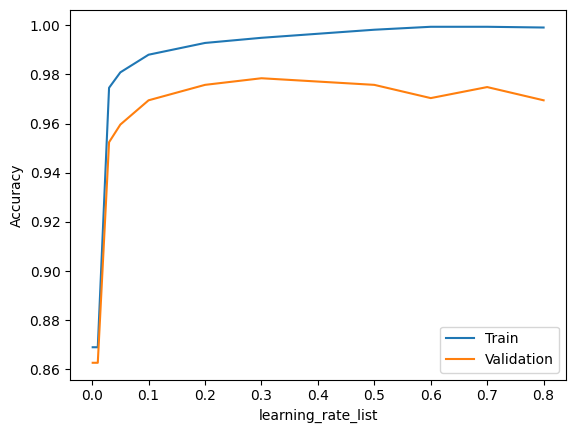

In [15]:
#plot graph
plt.plot(learning_rate_list,train_accuracy_list)
plt.plot(learning_rate_list,val_accuracy_list)
plt.xlabel('learning_rate_list')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

In [16]:
#find optimal learning rate from list 
index=np.argmax(val_accuracy_list)
learning_rate=learning_rate_list[index]
learning_rate

0.3

In [17]:
[learning_rate,n_estimator,max_depth]

[0.3, 50, 6]

In [18]:
#train model with optimal hyper parameter
model=XGBClassifier(learning_rate=learning_rate,n_estimators=n_estimator,max_depth=max_depth,random_state=1234)
model.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [19]:
#Save the trained model as a pickle file for future predictions
pickle.dump(model,open("spam_xgbclassifier.pkl","wb"))